<a href="https://colab.research.google.com/github/smsmorsalin/Face_Recognition_System/blob/main/student_placement_classification_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [110]:
df = pd.read_csv('/content/placement.csv')

In [111]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [112]:
print(df.ndim)
print(df.shape)

2
(100, 4)


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [114]:
# delete/remove unnessesary column.
df = df.iloc[:,1:]


print(df.shape)
df.head()

(100, 3)


,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


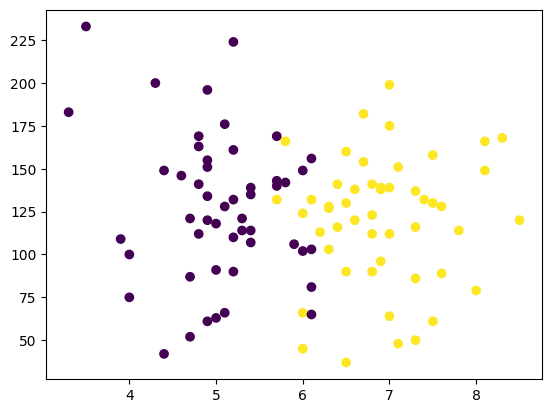

In [115]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])

In [116]:
#independent Variables
x = df.iloc[:,0:2]
#dependent Variables
y = df.iloc[:,-1]

In [117]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [118]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [119]:
#divide data for training(90%) for test(10%)

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1)

In [120]:
x_train

,cgpa,iq
55,7.8,114.0
38,6.5,160.0
68,4.0,75.0
14,6.1,103.0
26,7.0,199.0
...,...,...
72,7.3,116.0
64,7.0,64.0
20,6.6,120.0
80,4.9,196.0


In [121]:
x_test

,cgpa,iq
5,7.1,48.0
97,6.7,182.0
7,5.0,63.0
1,5.9,106.0
75,4.8,169.0
24,4.7,121.0
66,6.9,96.0
76,4.9,155.0
54,6.4,141.0
13,6.4,116.0


In [122]:
y_train

,placement
55,1
38,1
68,0
14,0
26,1
...,...
72,1
64,1
20,1
80,0


In [123]:
y_test

,placement
5,1
97,1
7,0
1,0
75,0
24,0
66,1
76,0
54,1
13,1


In [124]:
#transform to fit for the model train
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_train

array([[ 1.54754132e+00, -2.53232703e-01],
       [ 4.27798992e-01,  9.10344867e-01],
       [-1.72555164e+00, -1.23974412e+00],
       [ 8.32628911e-02, -5.31479513e-01],
       [ 8.58469118e-01,  1.89685628e+00],
       [ 1.28913924e+00, -1.59387642e+00],
       [-6.91943336e-01, -8.60316652e-01],
       [ 6.86201068e-01,  4.29736740e-01],
       [-2.87113418e-03,  6.32098057e-01],
       [ 1.37527327e+00,  1.00899601e-01],
       [-6.05809311e-01, -2.53232703e-01],
       [-1.38101554e+00,  6.32098057e-01],
       [ 5.13933017e-01,  3.53851246e-01],
       [-2.87113418e-03, -1.99859906e+00],
       [-2.15622177e+00,  2.75689188e+00],
       [-1.81168566e+00, -3.79708526e-01],
       [ 1.28913924e+00,  1.51489930e-01],
       [-6.91943336e-01,  2.52923540e+00],
       [ 8.58469118e-01,  3.79146411e-01],
       [ 7.72335093e-01,  3.79146411e-01],
       [-1.38101554e+00, -2.07448455e+00],
       [-7.78077362e-01, -1.46740060e+00],
       [-5.19675286e-01, -2.53232703e-01],
       [ 1.

In [125]:
x_test = scaler.transform(x_test)
x_test

array([[ 0.94460314, -1.92271356],
       [ 0.60006704,  1.46683849],
       [-0.86421139, -1.5432861 ],
       [-0.08900516, -0.45559402],
       [-1.03647944,  1.13800135],
       [-1.12261346, -0.07616655],
       [ 0.77233509, -0.70854567],
       [-0.95034541,  0.78386904],
       [ 0.34166497,  0.42973674],
       [ 0.34166497, -0.20264237]])

In [126]:
clf = LogisticRegression()
#Logistic Regression model training
clf.fit(x_train,y_train)

LogisticRegression()

In [127]:
y_pred = clf.predict(x_test)
print('y_test:\n',y_test)
print('y_pred: ',y_pred)

y_test:
 5     1
97    1
7     0
1     0
75    0
24    0
66    1
76    0
54    1
13    1
Name: placement, dtype: int64
y_pred:  [1 1 0 0 0 0 1 0 1 1]


In [128]:
accuracy_score(y_test,y_pred)

1.0

<Axes: >

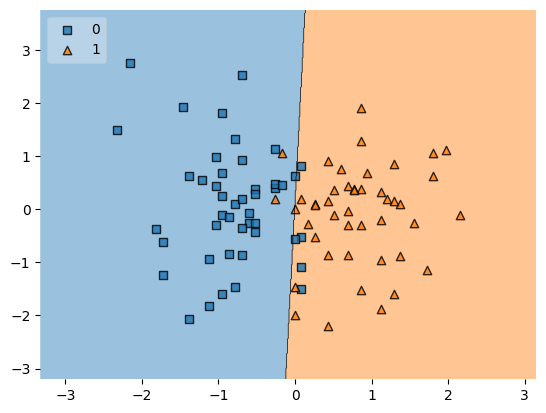

In [130]:
#visualize
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train,y_train.values,clf=clf, legend=2)

In [131]:
#to deploy another environment/website convert this model into a file
import pickle

pickle.dump(clf,open('model.pkl','wb'))